# Announcement-on-ML
<a href='http://www.kgptalkie.com' target="_blank"> <img src='https://github.com/laxmimerit/Important-Announcement-on-ML/raw/master/kgptalkie_strips.png'/></a>

# ML Resources
|  ML Course | Description |
|:---|:---|
| [**Data Visualization in Python Masterclass™: Beginners to Pro**](https://bit.ly/udemy95off_kgptalkie) |  Learn to build Machine Learning and Deep Learning models using Python and its libraries like Scikit-Learn, Keras, and TensorFlow. |
| [**Python for Machine Learning: A Step-by-Step Guide**](https://bit.ly/ml-ds-project) | Learn to build Machine Learning and Deep Learning models using Python and its libraries like Scikit-Learn, Keras, and TensorFlow. |
| [**Deep Learning for Beginners with Python**](https://bit.ly/dl-with-python) | Neural Networks, TensorFlow, ANN, CNN, RNN, LSTM, Transfer Learning and Much More. |
| [**Python for Linear Regression in Machine Learning**](https://bit.ly/regression-python) | Learn to build Linear Regression models using Python and its libraries like Scikit-Learn. |
| [**Introduction to Spacy 3 for Natural Language Processing**](https://bit.ly/spacy-intro) | Learn to build Natural Language Processing models using Python and its libraries like Spacy. |
| [**Advanced Machine Learning and Deep Learning Projects**](https://bit.ly/kgptalkie_ml_projects) | Learn to build Advanced Machine Learning and Deep Learning models using Python and transformer models like BERT, GPT-2, and XLNet. |
| [**Natural Language Processing in Python for Beginners**](https://bit.ly/intro_nlp) | Learn to build Natural Language Processing Projects using Spacy, NLTK, and Gensim, and transformer models like BERT, GPT-2, and XLNet. |
| [**Deployment of Machine Learning Models in Production in Python**](https://bit.ly/bert_nlp) |  Learn to deploy Machine Learning and Deep Learning models using Python and its libraries like Flask, Streamlit, and NGINX. |
| [**R 4.0 Programming for Data Science - Beginners to Pro**](https://bit.ly/r4-ml) | Learn to build Machine Learning and Deep Learning models using R and its libraries like caret, tidyverse, and keras. |


# Fine Tuning DistilBERT, MobileBERT and TinyBERT for Fake News Detection

## Text Classification Architecture

https://www.kaggle.com/c/fake-news/data

- Text classification is one of the most common tasks in NLP; it can be used for a broad range of applications, such as tagging customer feedback into categories or routing support tickets according to their language.

- smam classification, sentiment classification, toxic comment, emotion classification etc.


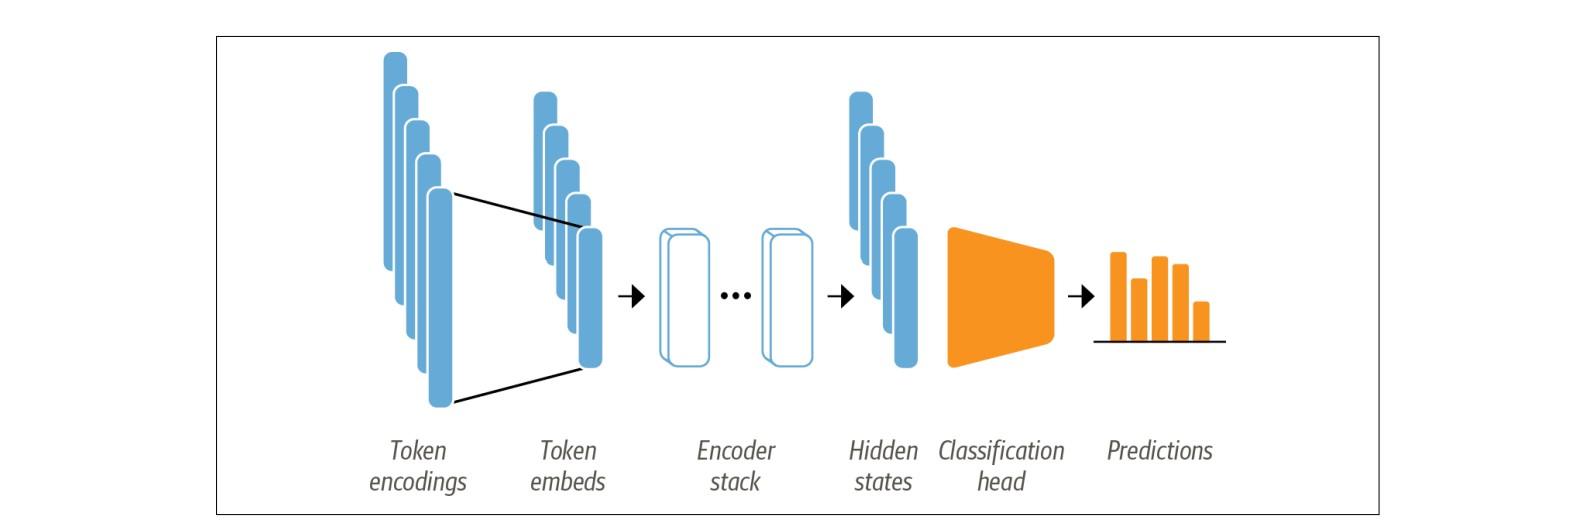

## Coding

In [1]:
# !pip install -U transformers
# !pip install -U accelerate
# !pip install -U datasets
# !pip install -U bertviz
# !pip install -U umap-learn
# !pip install seaborn --upgrade

# !pip install -U openpyxl

# Don't do in production. Doing now to keep output clean for understanding
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd

df = pd.read_excel("https://github.com/laxmimerit/All-CSV-ML-Data-Files-Download/raw/master/fake_news.xlsx")
df

,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1
...,...,...,...,...,...
20795,20795,Rapper T.I.: Trump a ’Poster Child For White S...,Jerome Hudson,Rapper T. I. unloaded on black celebrities who...,0
20796,20796,"N.F.L. Playoffs: Schedule, Matchups and Odds -...",Benjamin Hoffman,When the Green Bay Packers lost to the Washing...,0
20797,20797,Macy’s Is Said to Receive Takeover Approach by...,Michael J. de la Merced and Rachel Abrams,The Macy’s of today grew from the union of sev...,0
20798,20798,"NATO, Russia To Hold Parallel Exercises In Bal...",Alex Ansary,"NATO, Russia To Hold Parallel Exercises In Bal...",1


In [3]:
df.info()
df.isnull().sum()
df = df.dropna()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20800 entries, 0 to 20799
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      20800 non-null  int64 
 1   title   20242 non-null  object
 2   author  18843 non-null  object
 3   text    20757 non-null  object
 4   label   20800 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 812.6+ KB


id        0
title     0
author    0
text      0
label     0
dtype: int64

In [4]:
df['label'].value_counts()

label
0    10361
1     7920
Name: count, dtype: int64

## Dataset Analysis

In [5]:
import matplotlib.pyplot as plt


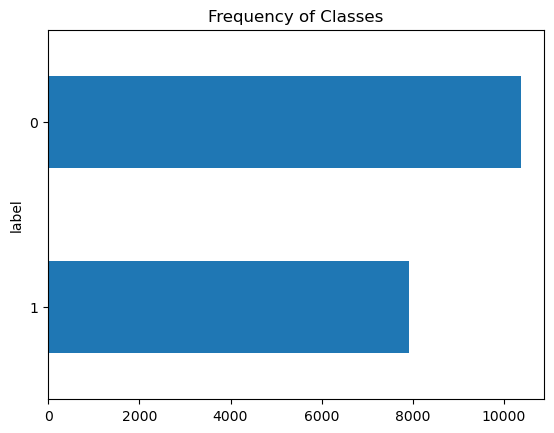

In [6]:
label_counts = df['label'].value_counts(ascending=True)
label_counts.plot.barh()
plt.title("Frequency of Classes")
plt.show()

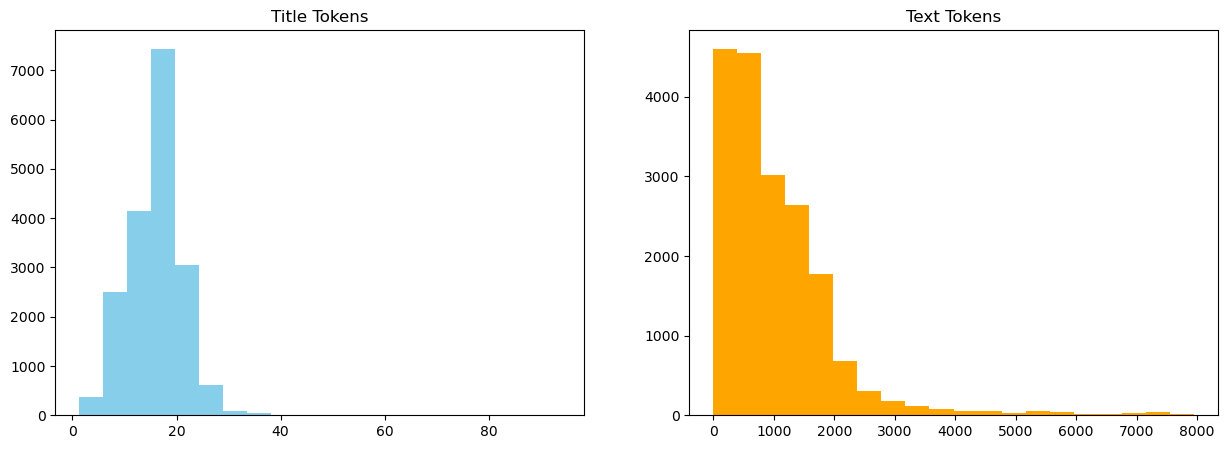

In [7]:
# average number of tokens in title and text
df['title_tokens'] = df['title'].apply(lambda x: len(x.split())*1.3)
df['text_tokens'] = df['text'].apply(lambda x: len(x.split())*1.3)

df['title_tokens'].mean(), df['text_tokens'].mean()

# plot in 1x2 grid
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# plot title tokens
ax[0].hist(df['title_tokens'], bins=20, color='skyblue')
ax[0].set_title('Title Tokens')

# plot text tokens
ax[1].hist(df['text_tokens'], bins=20, color='orange')
ax[1].set_title('Text Tokens')

plt.show()

## Data Loader and Train Test Split

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, stratify=df['label'])
test, validation = train_test_split(test, test_size=1/3, stratify=test['label'])

train.shape, test.shape, validation.shape

((12796, 7), (3656, 7), (1829, 7))

In [9]:
from datasets import Dataset, DatasetDict

dataset = DatasetDict(
    {'train':Dataset.from_pandas(train, preserve_index=False),
     'test':Dataset.from_pandas(test, preserve_index=False),
     'validation': Dataset.from_pandas(validation, preserve_index=False)
     }
     
)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'author', 'text', 'label', 'title_tokens', 'text_tokens'],
        num_rows: 12796
    })
    test: Dataset({
        features: ['id', 'title', 'author', 'text', 'label', 'title_tokens', 'text_tokens'],
        num_rows: 3656
    })
    validation: Dataset({
        features: ['id', 'title', 'author', 'text', 'label', 'title_tokens', 'text_tokens'],
        num_rows: 1829
    })
})

## Tokenization of the Emotion/Sentiment Data

In [10]:
dataset['train'][0], dataset['train'][1]

({'id': 17617,
  'title': 'De Blasio administration finds a way to ruin food trucks',
  'author': '# 1 NWO Hatr',
  'text': 'New York Post – by Michael Gartland \nThe de Blasio administration is trying to limit the number of food trucks in the city by claiming that each hot-dog and kabob cart causes more pollution than a truck ride to Los Angeles. \nDeputy Health Commissioner Corinne Schiff made the claim at a City Council hearing Wednesday, in an apparent effort to sink a bill that would nearly double the number of food-vendor permits in the city by 2023. \n“Meat grilling is a significant source of air pollution in the city,” Schiff said. “One additional vendor grilling meat emits an amount of particle pollution in one day equivalent to what a diesel truck emits driving 3,500 miles.” \nThe new bill would boost the number of permits to 8,000 by 2023 and also create an enforcement team to sniff out violations. \nSince 1983, the number of street-food vending permits has remained steady a

## Tokenization of the Text Data

In [11]:
from transformers import AutoTokenizer

text = "Machine learning is awesome!! Thanks KGP Talkie."

model_ckpt = "distilbert-base-uncased"
distilbert_tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
distilbert_tokens = distilbert_tokenizer.tokenize(text)

model_ckpt = "google/mobilebert-uncased"
mobilebert_tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
mobilebert_tokens = mobilebert_tokenizer.tokenize(text)

model_ckpt = "huawei-noah/TinyBERT_General_4L_312D"
tinybert_tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
tinybert_tokens = tinybert_tokenizer.tokenize(text)



In [12]:
distilbert_tokenizer, mobilebert_tokenizer, tinybert_tokenizer

distilbert_tokens, mobilebert_tokens, tinybert_tokens

print()

In [13]:
def tokenize(batch):
    temp = distilbert_tokenizer(batch['title'], padding=True, truncation=True)
    return temp

print(tokenize(dataset['train'][:2]))

{'input_ids': [[101, 2139, 1038, 8523, 3695, 3447, 4858, 1037, 2126, 2000, 10083, 2833, 9322, 102, 0, 0, 0, 0, 0, 0, 0], [101, 7726, 2015, 5247, 1002, 1016, 1012, 26314, 2006, 5053, 3688, 6604, 1010, 1017, 2335, 2062, 2084, 2037, 2647, 14562, 102]], 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}


In [14]:
encoded_dataset = dataset.map(tokenize, batched=True, batch_size=None)

Map:   0%|          | 0/12796 [00:00<?, ? examples/s]

Map:   0%|          | 0/3656 [00:00<?, ? examples/s]

Map:   0%|          | 0/1829 [00:00<?, ? examples/s]

In [15]:
df

,id,title,author,text,label,title_tokens,text_tokens
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1,18.2,1066.0
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0,11.7,923.0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1,9.1,1645.8
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1,13.0,724.1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \nAn Iranian woman has been sentenced to...,1,18.2,200.2
...,...,...,...,...,...,...,...
20795,20795,Rapper T.I.: Trump a ’Poster Child For White S...,Jerome Hudson,Rapper T. I. unloaded on black celebrities who...,0,11.7,399.1
20796,20796,"N.F.L. Playoffs: Schedule, Matchups and Odds -...",Benjamin Hoffman,When the Green Bay Packers lost to the Washing...,0,14.3,1456.0
20797,20797,Macy’s Is Said to Receive Takeover Approach by...,Michael J. de la Merced and Rachel Abrams,The Macy’s of today grew from the union of sev...,0,19.5,1041.3
20798,20798,"NATO, Russia To Hold Parallel Exercises In Bal...",Alex Ansary,"NATO, Russia To Hold Parallel Exercises In Bal...",1,10.4,347.1


In [16]:
# label2id, id2label
label2id = {'Fake': 0, 'Real': 1}
id2label = {0: 'Fake', 1: 'Real'}

## Model Building

In [17]:
from transformers import AutoModel 
import torch

In [18]:
model_ckpt = "distilbert-base-uncased"
model = AutoModel.from_pretrained(model_ckpt)

In [19]:
model.config.id2label
model.config

DistilBertConfig {
  "_name_or_path": "distilbert-base-uncased",
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.35.2",
  "vocab_size": 30522
}

## Fine-Tuning Transformers

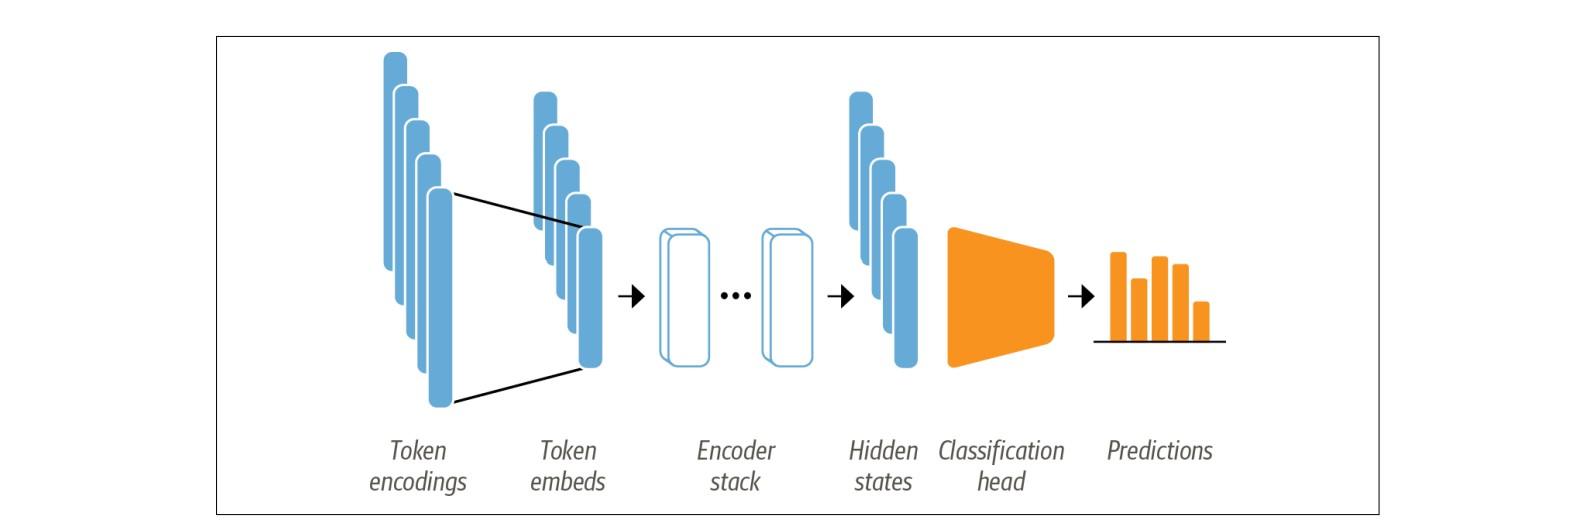

- `AutoModelForSequenceClassification` model has a classification head on top of the pretrained model outputs

- The first thing we need is a pretrained BERT-like model.
- The only slight modification is that we use the `AutoModelForSequenceClassification` model instead of AutoModel.
- The difference is that the `AutoModelForSequenceClassification` model has a classification head on top of the pretrained model outputs, which can be easily trained with the base model.

In [20]:
from transformers import AutoModelForSequenceClassification, AutoConfig

num_labels = len(label2id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = AutoConfig.from_pretrained(model_ckpt, label2id=label2id, id2label=id2label)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, config=config).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.weight', 'classifier.weight', 'classifier.bias', 'pre_classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
model.config

DistilBertConfig {
  "_name_or_path": "distilbert-base-uncased",
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "id2label": {
    "0": "Fake",
    "1": "Real"
  },
  "initializer_range": 0.02,
  "label2id": {
    "Fake": 0,
    "Real": 1
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.35.2",
  "vocab_size": 30522
}

In [22]:
from transformers import TrainingArguments

batch_size = 32
training_dir = "train_dir"

training_args = TrainingArguments(output_dir=training_dir,
                                  overwrite_output_dir = True,
                                  num_train_epochs = 2,
                                  learning_rate = 2e-5,
                                  per_device_train_batch_size = batch_size,
                                  per_device_eval_batch_size = batch_size,
                                  weight_decay = 0.01,
                                  evaluation_strategy = 'epoch',
                                  disable_tqdm = False
)

In [23]:
# Build compute metrics function
# !pip install evaluate
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics_evaluate(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)



In [24]:
# use sklearn to build compute metrics
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    f1 = f1_score(labels, preds, average="weighted")
    acc = accuracy_score(labels, preds)

    return {"accuracy": acc, "f1": f1}


## Build Model and Trainer

In [25]:
from transformers import Trainer

trainer = Trainer(model=model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset = encoded_dataset['train'],
                  eval_dataset = encoded_dataset['validation'],
                  tokenizer = distilbert_tokenizer)

In [26]:
trainer.train()

  0%|          | 0/400 [00:00<?, ?it/s]

You're using a DistilBertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


  0%|          | 0/58 [00:00<?, ?it/s]

{'eval_loss': 0.12501688301563263, 'eval_accuracy': 0.9491525423728814, 'eval_f1': 0.9492058247421177, 'eval_runtime': 2.6628, 'eval_samples_per_second': 686.879, 'eval_steps_per_second': 21.782, 'epoch': 1.0}
{'train_runtime': 82.2335, 'train_samples_per_second': 155.606, 'train_steps_per_second': 4.864, 'train_loss': 0.18730710983276366, 'epoch': 1.0}


TrainOutput(global_step=400, training_loss=0.18730710983276366, metrics={'train_runtime': 82.2335, 'train_samples_per_second': 155.606, 'train_steps_per_second': 4.864, 'train_loss': 0.18730710983276366, 'epoch': 1.0})

## Model Evaluation

In [27]:
preds_output = trainer.predict(encoded_dataset['test'])
preds_output.metrics

  0%|          | 0/115 [00:00<?, ?it/s]

{'test_loss': 0.11998555064201355,
 'test_accuracy': 0.9504923413566739,
 'test_f1': 0.9505224990632086,
 'test_runtime': 7.8357,
 'test_samples_per_second': 466.583,
 'test_steps_per_second': 14.676}

In [28]:
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = encoded_dataset['test'][:]['label']

In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, labels=[0, 1], target_names=['Fake', 'Real']))

              precision    recall  f1-score   support

        Fake       0.96      0.95      0.96      2072
        Real       0.94      0.95      0.94      1584

    accuracy                           0.95      3656
   macro avg       0.95      0.95      0.95      3656
weighted avg       0.95      0.95      0.95      3656



## Benchmarking

In [34]:
model_dict = {'bert_base': 'bert-base-uncased',
              'distilbert': 'distilbert-base-uncased',
              'mobilebert': 'google/mobilebert-uncased',
              'tinybert': 'huawei-noah/TinyBERT_General_4L_312D'}

def train_model(model_name):
  model_ckpt = model_dict[model_name]
  tokenizer = AutoTokenizer.from_pretrained(model_ckpt)
  model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=2).to(device)

  def batch_tokenizer_local(batch):
    temp = tokenizer(batch['text'], padding=True, truncation=True)
    return temp
  

  encoded_dataset = dataset.map(batch_tokenizer_local, batched=True, batch_size=None)


  trainer = Trainer(model = model, args=training_args, 
                    compute_metrics=compute_metrics,train_dataset=encoded_dataset['train'],
                    eval_dataset=encoded_dataset['validation'],
                    tokenizer=tokenizer)

  trainer.train()

  preds = trainer.predict(encoded_dataset['test'])

  return   preds.metrics


model_performance = {}
for model_name in model_dict.keys():
  print(f"Training model: {model_name}")
  model_performance[model_name] = train_model(model_name)


Training model: bert_base


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/12796 [00:00<?, ? examples/s]

Map:   0%|          | 0/3656 [00:00<?, ? examples/s]

Map:   0%|          | 0/1829 [00:00<?, ? examples/s]

  0%|          | 0/400 [00:00<?, ?it/s]

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


In [ ]:
model_performance

# Model Load and Save